<a href="https://colab.research.google.com/github/sorayanakhbaty/Klasifikasi-HoaxNews/blob/main/FAKENEWS_PP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORT LIBRARY**

In [ ]:
!pip install gensim

In [ ]:
!pip install wordcloud

In [ ]:
# =======================
# 1. IMPORT LIBRARY
# =======================

import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

# **DATASET FAKE NEWS**

In [ ]:
# =======================
# 2. LOAD DATA
# =======================

valid_df = pd.read_csv('detik.csv')
hoax_df = pd.read_csv('turnbackhoax.csv')

# **LABELLING DATA**

In [ ]:
# =======================
# 3. LABELLING DATA
# =======================
df_hoax = pd.DataFrame({'text': hoax_df['Title'], 'label': 'hoax'})
df_valid = pd.DataFrame({'text': valid_df['Title'], 'label': 'valid'})
combined_df = pd.concat([df_hoax, df_valid], ignore_index=True)


In [ ]:
valid_df

,Title,Text,Date,Link,Category
0,"Bekal ""Strategic Foresight"" untuk Para Capres",Pandangan jauh ke depan (foresight) perlu dimi...,"detikNewsKamis, 02 Nov 2023 11:15 WIB",https://news.detik.com/kolom/d-7013788/bekal-s...,Politik
1,Mendag Zulhas Jelaskan Pengaruh Geopolitik Ter...,Menteri Perdagangan RI Zulkifli Hasan menjadi ...,"detikFinanceKamis, 02 Nov 2023 11:15 WIB",https://finance.detik.com/berita-ekonomi-bisni...,Politik
2,Kapan Pengumuman TKN Prabowo-Gibran? Ini Jawab...,Ketua Harian Partai Gerindra Dasco mengatakan ...,"detikNewsKamis, 02 Nov 2023 11:11 WIB",https://news.detik.com/berita/d-7015092/kapan-...,Politik
3,Relawan Pengusaha Muda Dorong Ekonomi Indonesi...,Relawan Pengusaha Muda Nasional (REPNAS) Indon...,"detikNewsKamis, 02 Nov 2023 11:04 WIB",https://news.detik.com/berita/d-7015074/relawa...,Politik
4,Panda Nababan Sentil Gibran yang Mudah Berkhia...,Politikus Senior PDI Perjuangan Panda Nababan ...,"detikSumbagselKamis, 02 Nov 2023 10:25 WIB",https://www.detik.com/sumbagsel/berita/d-70149...,Politik
...,...,...,...,...,...
2155,Warga Bantargebang Tolak Pembangunan PSEL: Kam...,"Warga Bantargebang, Kota Bekasi, menolak renca...","detikNewsSabtu, 07 Okt 2023 17:07 WIB",https://news.detik.com/berita/d-6970285/warga-...,Olahraga
2156,Polda Metro Dalami Foto Pertemuan SYL dan Firl...,Polda Metro Jaya dalami foto pertemuan Ketua K...,"detikSumbagselSabtu, 07 Okt 2023 16:49 WIB",https://www.detik.com/sumbagsel/hukum-dan-krim...,Olahraga
2157,"Gelar World Walking Day, Walkot Tangerang: Mud...",Pemerintah Kota (Pemkot) Tangerang sukses meng...,"detikNewsSabtu, 07 Okt 2023 16:06 WIB",https://news.detik.com/berita/d-6970204/gelar-...,Olahraga
2158,"Punya Gen Pemicu Alzheimer, Chris Hemsworth Ma...",Hemsworth disebut memiliki risiko tinggi mengi...,"detikHealthSabtu, 07 Okt 2023 16:00 WIB",https://health.detik.com/berita-detikhealth/d-...,Olahraga


In [ ]:
hoax_df

,Title,Text,Date,Link,Category
0,[SALAH] Perhelatan Puncak Balapan Formula E Se...,Hasil Periksa Fakta Novita Kusuma Wardhani. In...,"Juni 17, 2022",https://turnbackhoax.id/2022/06/17/salah-perhe...,Olahraga
1,[SALAH] “HRS dilaporkan tewas tertabrak Unta p...,Informasi palsu. Berdasar pada penggunaan kata...,"September 22, 2020",https://turnbackhoax.id/2020/09/22/salah-hrs-d...,Olahraga
2,[SALAH] Formula E Tidak Disiarkan oleh TV Nasi...,Hasil Periksa Fakta Gabriela Nauli Sinaga (Uni...,"Juni 13, 2022",https://turnbackhoax.id/2022/06/13/salah-formu...,Olahraga
3,[SALAH]: Formula E Jakarta Masuk Rekor Dunia S...,Informasi menyesatkan. Berdasarkan dari pember...,"Juni 6, 2022",https://turnbackhoax.id/2022/06/06/salah-formu...,Olahraga
4,[SALAH]: Barang-barang Pemberian Pembalap Moto...,Bukan barang-barang yang diberikan kepada peno...,"April 1, 2022",https://turnbackhoax.id/2022/04/01/salah-baran...,Olahraga
...,...,...,...,...,...
2147,[SALAH]: Seorang Ibu-Ibu Meninggal Akibat Terp...,Debunk ini berisi informasi yang menyebutkan b...,"Juli 2, 2018",https://turnbackhoax.id/2018/07/02/salah-seora...,Olahraga
2148,[BENAR]: Maradona Bantah Kabar Dirinya Meningg...,Debunk ini berisi bantahan dari Legenda sepakb...,"Juni 29, 2018",https://turnbackhoax.id/2018/06/29/benar-marad...,Olahraga
2149,[BENAR] Wakapolri Tidak Pernah Beri Pernyataan...,Wakapolri Komjen Pol Syafruddin memberikan kla...,"Juni 29, 2018",https://turnbackhoax.id/2018/06/29/benar-wakap...,Olahraga
2150,[BENAR] “Foto wanita Iran yang menonton Piala ...,“Seorang pengguna Reddit mengunggah foto yang ...,"Juni 25, 2018",https://turnbackhoax.id/2018/06/25/benar-foto-...,Olahraga


# **PENGGABUNGAN DATASET**

In [ ]:
# Gabungkan data
combined_df

,text,label
0,[SALAH] Perhelatan Puncak Balapan Formula E Se...,hoax
1,[SALAH] “HRS dilaporkan tewas tertabrak Unta p...,hoax
2,[SALAH] Formula E Tidak Disiarkan oleh TV Nasi...,hoax
3,[SALAH]: Formula E Jakarta Masuk Rekor Dunia S...,hoax
4,[SALAH]: Barang-barang Pemberian Pembalap Moto...,hoax
...,...,...
4307,Warga Bantargebang Tolak Pembangunan PSEL: Kam...,valid
4308,Polda Metro Dalami Foto Pertemuan SYL dan Firl...,valid
4309,"Gelar World Walking Day, Walkot Tangerang: Mud...",valid
4310,"Punya Gen Pemicu Alzheimer, Chris Hemsworth Ma...",valid


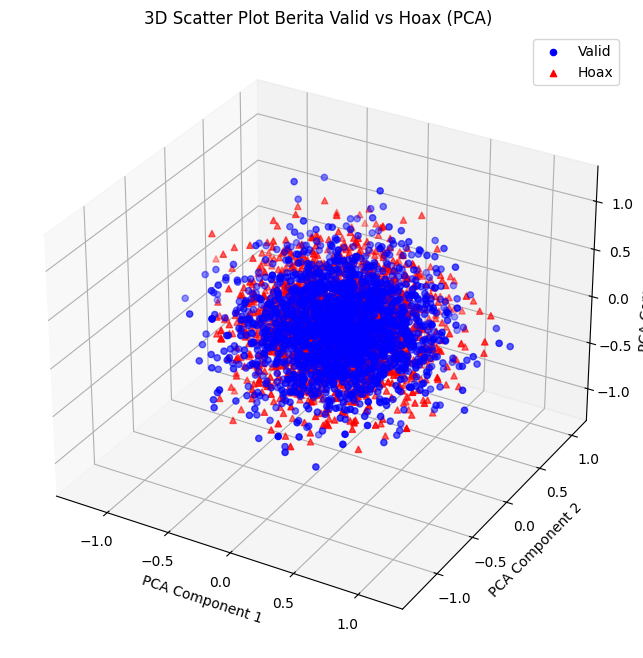

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Contoh data vektorisasi dummy (ganti dengan hasil TF-IDF asli jika ada)
X = np.random.rand(len(combined_df), 100)  # 100 = jumlah fitur, sesuaikan

# Reduksi dimensi jadi 3 komponen utama untuk visualisasi 3D
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# Ambil label dan pastikan lowercase
labels = combined_df['label'].str.lower().values

# Visualisasi 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot berita valid (biru)
ax.scatter(X_pca[labels == 'valid', 0],
           X_pca[labels == 'valid', 1],
           X_pca[labels == 'valid', 2],
           c='blue', label='Valid', marker='o')

# Plot berita hoax (merah)
ax.scatter(X_pca[labels == 'hoax', 0],
           X_pca[labels == 'hoax', 1],
           X_pca[labels == 'hoax', 2],
           c='red', label='Hoax', marker='^')

# Label sumbu dan judul
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('3D Scatter Plot Berita Valid vs Hoax (PCA)')

# Tampilkan legenda dan grafik
ax.legend()
plt.show()

# **DATA PROCESSING**

In [ ]:
# =======================
# 4. PEMROSESAN DATA
# =======================

combined_df.dropna(subset=['text'], inplace=True)
combined_df = combined_df[combined_df['text'].apply(isinstance, args=(str,))]

# **PROSES STOPWORD**

In [ ]:
import nltk

nltk.download('stopwords')
stopwords = nltk.corpus.stopwords.words('indonesian')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
print('\n'.join(stopwords))

ada
adalah
adanya
adapun
agak
agaknya
agar
akan
akankah
akhir
akhiri
akhirnya
aku
akulah
amat
amatlah
anda
andalah
antar
antara
antaranya
apa
apaan
apabila
apakah
apalagi
apatah
artinya
asal
asalkan
atas
atau
ataukah
ataupun
awal
awalnya
bagai
bagaikan
bagaimana
bagaimanakah
bagaimanapun
bagi
bagian
bahkan
bahwa
bahwasanya
baik
bakal
bakalan
balik
banyak
bapak
baru
bawah
beberapa
begini
beginian
beginikah
beginilah
begitu
begitukah
begitulah
begitupun
bekerja
belakang
belakangan
belum
belumlah
benar
benarkah
benarlah
berada
berakhir
berakhirlah
berakhirnya
berapa
berapakah
berapalah
berapapun
berarti
berawal
berbagai
berdatangan
beri
berikan
berikut
berikutnya
berjumlah
berkali-kali
berkata
berkehendak
berkeinginan
berkenaan
berlainan
berlalu
berlangsung
berlebihan
bermacam
bermacam-macam
bermaksud
bermula
bersama
bersama-sama
bersiap
bersiap-siap
bertanya
bertanya-tanya
berturut
berturut-turut
bertutur
berujar
berupa
besar
betul
betulkah
biasa
biasanya
bila
bilakah
bisa
bisakah
boleh


In [ ]:
import pandas as pd
# Buat dataframe dari stopwords
stopwords_df = pd.DataFrame(stopwords, columns=['Stopwords'])
# Tampilkan dataframe
stopwords_df

,Stopwords
0,ada
1,adalah
2,adanya
3,adapun
4,agak
...,...
753,wong
754,yaitu
755,yakin
756,yakni


# **PROSES TOKENISASI**

In [ ]:
import gensim

def preprocess(text):
  result = []
  for token in gensim.utils.simple_preprocess(text):
    # Use the correctly named 'stopwords' variable
    if token not in gensim.parsing.preprocessing.STOPWORDS and len(token) > 3 and token not in stopwords:
      result.append(token)
  return result

In [ ]:
combined_df['tokenized_text'] = combined_df['text'].apply(preprocess)

# Create a table (DataFrame) to display tokenized text
tokenization_table = combined_df[['text', 'tokenized_text']].copy()

# Display the table
print("Hasil Tokenisasi:")
display(tokenization_table)


Hasil Tokenisasi:


,text,tokenized_text
0,[SALAH] Perhelatan Puncak Balapan Formula E Se...,"[salah, perhelatan, puncak, balapan, formula, ..."
1,[SALAH] “HRS dilaporkan tewas tertabrak Unta p...,"[salah, dilaporkan, tewas, tertabrak, unta, ac..."
2,[SALAH] Formula E Tidak Disiarkan oleh TV Nasi...,"[salah, formula, disiarkan, nasional]"
3,[SALAH]: Formula E Jakarta Masuk Rekor Dunia S...,"[salah, formula, jakarta, masuk, rekor, dunia,..."
4,[SALAH]: Barang-barang Pemberian Pembalap Moto...,"[salah, barang, barang, pemberian, pembalap, m..."
...,...,...
4307,Warga Bantargebang Tolak Pembangunan PSEL: Kam...,"[warga, bantargebang, tolak, pembangunan, psel..."
4308,Polda Metro Dalami Foto Pertemuan SYL dan Firl...,"[polda, metro, dalami, foto, pertemuan, firli,..."
4309,"Gelar World Walking Day, Walkot Tangerang: Mud...","[gelar, world, walking, walkot, tangerang, mud..."
4310,"Punya Gen Pemicu Alzheimer, Chris Hemsworth Ma...","[pemicu, alzheimer, chris, hemsworth, mati, ma..."


# **DATA CLEANING**

In [ ]:
# =======================
# 5. CLEANING (NLP)
# =======================

import nltk
nltk.download('stopwords', quiet=True)
# nltk.download('punkt', quiet=True) # Punkt download might not be necessary with regex tokenization
indo_stopwords = set(nltk.corpus.stopwords.words('indonesian'))

def preprocess_text(text):
    text = text.lower()
    # Remove double quotes (both standard and smart quotes)
    text = text.replace('"', '').replace('”', '').replace('“', '')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    # Use regex for tokenization instead of word_tokenize
    tokens = re.findall(r'\b\w+\b', text)
    tokens = [word for word in tokens if word not in indo_stopwords]
    return ' '.join(tokens)

combined_df['cleaned_text'] = combined_df['text'].apply(preprocess_text)

# **EDA (EXSPLORATORY DATA ANALYSIS)**

# **WORDCLOUD**

In [ ]:
# Plot valid hoax wordcloud

import matplotlib.pyplot as plt
from wordcloud import WordCloud

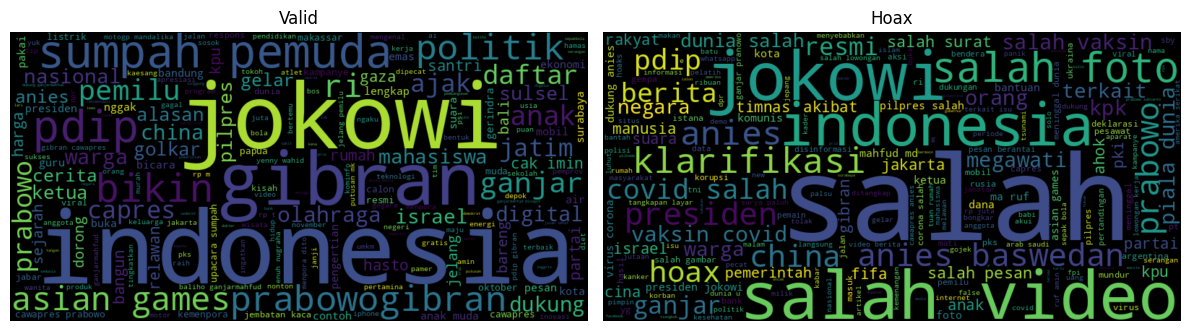

In [ ]:
# Filter data for valid and hoax labels
valid_text = " ".join(combined_df[combined_df['label'] == 'valid']['cleaned_text'].dropna())
hoax_text = " ".join(combined_df[combined_df['label'] == 'hoax']['cleaned_text'].dropna())

# Generate Word Clouds
wordcloud_valid = WordCloud(width=800, height=400, background_color='black').generate(valid_text)
wordcloud_hoax = WordCloud(width=800, height=400, background_color='black').generate(hoax_text)

# Display Word Clouds
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_valid, interpolation='bilinear')
plt.axis("off")
plt.title("Valid")

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_hoax, interpolation='bilinear')
plt.axis("off")
plt.title("Hoax")

plt.tight_layout()
plt.show()

# **KATA UNIK**

In [ ]:
# kata unik dari dataset

all_cleaned_text = " ".join(combined_df['cleaned_text'].dropna())

# Tokenize the combined cleaned text

tokens = word_tokenize(all_cleaned_text)

# Get unique words
unique_words = set(tokens)

# Print the number of unique words and some examples
print(f"Jumlah kata unik: {len(unique_words)}")
print("Contoh kata unik:")
print(list(unique_words)[:20])

Jumlah kata unik: 8532
Contoh kata unik:
['rakitan', 'kekeringan', 'dicemooh', 'bukit', 'play', 'umat', 'dilarang', 'pendeteksi', 'bulutangkis', 'besutan', 'generasi', 'gebyar', 'khawatir', 'rudi', 'kematian', 'bahagia', 'diambil', 'dibeli', 'viralkan', 'aspirasi']


Jumlah kata unik: 8532

Frekuensi 20 kata teratas:


,Kata,Frekuensi
0,salah,1894
1,jokowi,334
2,indonesia,306
3,video,221
4,anies,218
5,gibran,146
6,foto,144
7,pdip,141
8,prabowo,129
9,dunia,111


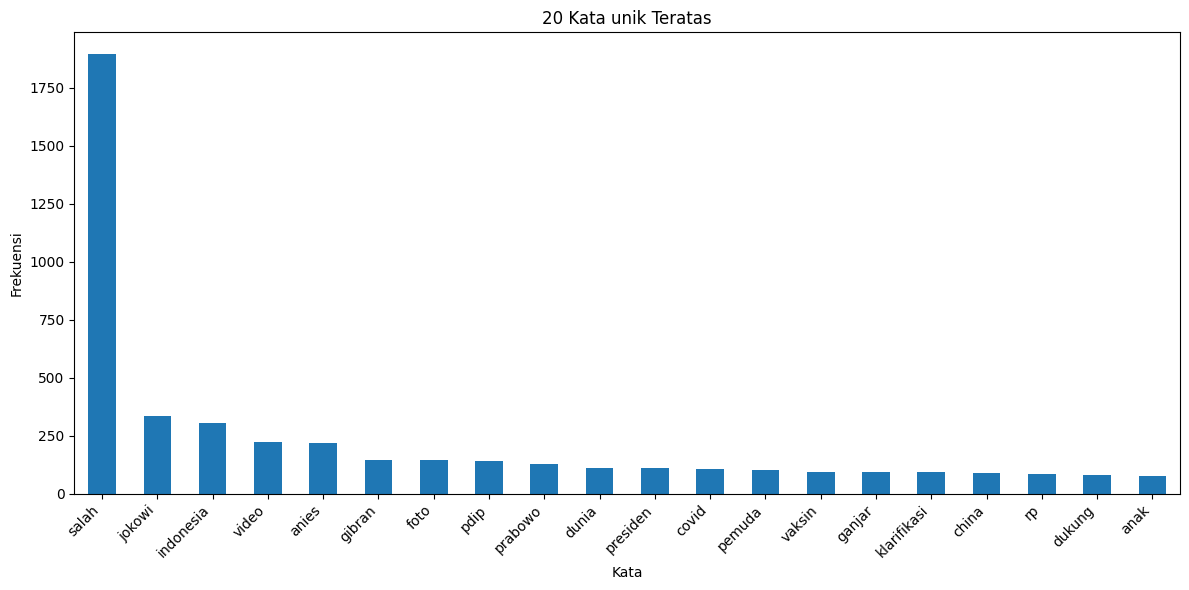

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize # Import word_tokenize

# Gabungkan semua teks yang sudah dibersihkan
all_cleaned_text = " ".join(combined_df['cleaned_text'].dropna())

# Tokenisasi teks yang sudah digabungkan
all_tokens = word_tokenize(all_cleaned_text)

# Hitung frekuensi setiap kata
word_counts = pd.Series(all_tokens).value_counts()

# Tampilkan jumlah kata unik
print(f"Jumlah kata unik: {len(word_counts)}")

# Tampilkan frekuensi 20 kata teratas dalam bentuk tabel
print("\nFrekuensi 20 kata teratas:")
top_20_words_df = word_counts.head(20).reset_index()
top_20_words_df.columns = ['Kata', 'Frekuensi']
display(top_20_words_df)

# Buat grafik frekuensi kata teratas
plt.figure(figsize=(12, 6))
word_counts.head(20).plot(kind='bar')
plt.title('20 Kata unik Teratas')
plt.xlabel('Kata')
plt.ylabel('Frekuensi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **TF-IDF REPRESENTATION**

In [ ]:
# =======================
# TF-IDF REPRESENTATION
# mengubah data teks menjadi representasi numerik (angka)
# =======================
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_vectorized = tfidf.fit_transform(combined_df['cleaned_text']).toarray()
y = combined_df['label']

# **DATA SPLIT**

In [ ]:
# =======================
# 6. SPLIT DATA (70:30)
# =======================

X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.3, random_state=42, stratify=y)

print(f"Ukuran data training: {len(X_train)}")
print(f"Ukuran data testing: {len(X_test)}")
print(f"Proporsi label di data training:\n{y_train.value_counts(normalize=True)}")
print(f"Proporsi label di data testing:\n{y_test.value_counts(normalize=True)}")

Ukuran data training: 3018
Ukuran data testing: 1294
Proporsi label di data training:
label
valid    0.500994
hoax     0.499006
Name: proportion, dtype: float64
Proporsi label di data testing:
label
valid    0.500773
hoax     0.499227
Name: proportion, dtype: float64


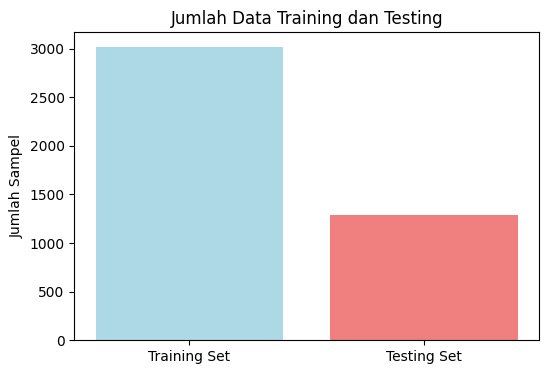

In [ ]:
import matplotlib.pyplot as plt
# Create a pie chart to visualize the train-test split
labels = ['Training Set', 'Testing Set']
sizes = [len(X_train), len(X_test)]
colors = ['lightblue', 'lightcoral']
explode = (0.1, 0)  # explode the 1st slice (i.e., 'Training Set')

# You can also create a bar chart for a different perspective
plt.figure(figsize=(6, 4))
plt.bar(labels, sizes, color=colors)
plt.title('Jumlah Data Training dan Testing')
plt.ylabel('Jumlah Sampel')
plt.show()

# **DATA TRAINING 70%**

In [ ]:
# =======================
# 7. TRAINING 70%
# =======================

import pandas as pd
from sklearn.model_selection import train_test_split

# Assuming combined_df is already loaded and has 'Text' and 'label' columns


# We use the same random_state and test_size as the previous split to ensure consistency
combined_df_train, combined_df_test = train_test_split(combined_df, test_size=0.3, random_state=42, stratify=combined_df['label']) # Use combined_df['label'] for stratify

# Display the 'Text' and 'label' columns of the training set
print("Sample of Training News Data:")
display(combined_df_train[['text', 'label']].head(10)) # Displaying the first few rows

Sample of Training News Data:


,text,label
3829,Mansion Sports Entertainment Group Makin Eksis...,valid
3505,Tiga Pejabat Unud Didakwa Paksa Ribuan Mahasis...,valid
3282,Spek dan Harga Toyota Alphard Mobil Andalan Pr...,valid
2455,Cerita Aboe Bakar Tak Sangka PKS Bisa Bersatu ...,valid
1642,[BENAR] Klarifikasi Gus Mus ( A. Mustofa Bisri...,hoax
2623,"Ramai Spanduk Gambar Petruk di Solo-Semarang, ...",valid
4151,2 Ketua KONI Tapsel Divonis 1 Tahun Penjara Pe...,valid
43,[SALAH] Investigasi Majalah Tempo Menyimpulkan...,hoax
667,[SALAH] Pesan Berantai “Pemerintah Menyediakan...,hoax
3984,Barcelona Mau Perpanjang Kontrak Frenkie de Jong,valid


In [ ]:
import numpy as np
import pandas as pd

# Assuming X_train and tfidf are already defined

# Get feature names from the TF-IDF vectorizer
feature_names = tfidf.get_feature_names_out()

print("Non-zero values in Training Data (X_train):")

# Iterate through a few samples in X_train and display non-zero values
num_samples_to_show = 5 # Display non-zero values for the first 5 samples

for i in range(min(num_samples_to_show, X_train.shape[0])):
    print(f"\nSample {i}:")
    # Get the indices of non-zero elements in the current sample
    non_zero_indices = X_train[i].nonzero()[0]

    if len(non_zero_indices) > 0:
        # Get the feature names and values for the non-zero elements
        non_zero_features = [feature_names[j] for j in non_zero_indices]
        non_zero_values = X_train[i, non_zero_indices]

        # Create a DataFrame to display the non-zero features and values
        non_zero_df = pd.DataFrame({'Feature': non_zero_features, 'TF-IDF Value': non_zero_values})
        display(non_zero_df)
    else:
        print("No non-zero values in this sample.")

Non-zero values in Training Data (X_train):

Sample 0:


,Feature,TF-IDF Value
0,bidang,0.344838
1,eksis,0.383827
2,entertainment,0.397659
3,group,0.350501
4,mansion,0.383827
5,sportaiment,0.397659
6,sports,0.383827



Sample 1:


,Feature,TF-IDF Value
0,bayar,0.356824
1,mahasiswa,0.310035
2,paksa,0.382246
3,pejabat,0.372384
4,ribuan,0.344754
5,spi,0.431809
6,unud,0.431809



Sample 2:


,Feature,TF-IDF Value
0,alphard,0.415721
1,andalan,0.430702
2,harga,0.309087
3,mobil,0.284193
4,prabowo,0.235651
5,spek,0.404101
6,subianto,0.358511
7,toyota,0.343530



Sample 3:


,Feature,TF-IDF Value
0,anies,0.219728
1,bakar,0.372589
2,bersatu,0.424910
3,cerita,0.334635
4,dukung,0.272412
5,pkb,0.364753
6,pks,0.328655
7,sangka,0.452881



Sample 4:


,Feature,TF-IDF Value
0,amin,0.241253
1,bisri,0.339756
2,gus,0.273642
3,klarifikasi,0.201431
4,ma,0.252657
5,menanggapi,0.327938
6,mus,0.339756
7,mustofa,0.339756
8,pernyataan,0.273642
9,rekayasa,0.311282


# **TRAINING MODEL RNN**

In [ ]:
# =======================
# 8. PERSIAPAN DATA UNTUK RNN
# =======================

le = LabelEncoder()
combined_df['label_encoded'] = le.fit_transform(combined_df['label'])

max_words = 10000
tokenizer = Tokenizer(num_words=max_words, split=' ')
tokenizer.fit_on_texts(combined_df['cleaned_text'].values)
X = tokenizer.texts_to_sequences(combined_df['cleaned_text'].values)

max_len = max([len(i) for i in X])
X_pad = pad_sequences(X, maxlen=max_len)

y_rnn = combined_df['label_encoded'].values

# Split data for RNN (using padded sequences and encoded labels)
X_train_pad, X_test_pad, y_train_rnn, y_test_rnn = train_test_split(X_pad, y_rnn, test_size=0.3, random_state=42, stratify=y_rnn)

In [ ]:
# =======================
# MEMBANGUN MODEL DENGAN SimpleRNN
# =======================

embedding_dim = 128

model = Sequential()
model.add(Embedding(max_words, embedding_dim, input_length=X_pad.shape[1]))
model.add(SpatialDropout1D(0.2))
model.add(SimpleRNN(100, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid')) # Output layer

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print("--- Arsitektur Model SimpleRNN ---")

--- Arsitektur Model SimpleRNN ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, SimpleRNN, Dense

model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_shape=(100,)),
    SpatialDropout1D(0.2),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 100, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

# **PENGUJIAN SISTEM DETEKSI**

In [ ]:
# =======================
# 9. PELATIHAN MODEL
# =======================

epochs = 10
batch_size = 64

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy']) # Compile the model

history = model.fit(
    X_train_pad, y_train_rnn,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, min_delta=0.0001)]
)

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.6229 - loss: 0.6385 - val_accuracy: 0.9238 - val_loss: 0.2288
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9639 - loss: 0.1156 - val_accuracy: 0.9338 - val_loss: 0.1495
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9785 - loss: 0.0653 - val_accuracy: 0.9636 - val_loss: 0.0916
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9988 - loss: 0.0131 - val_accuracy: 0.9801 - val_loss: 0.0791
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9998 - loss: 0.0058 - val_accuracy: 0.9801 - val_loss: 0.0898
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9997 - loss: 0.0060 - val_accuracy: 0.9735 - val_loss: 0.0838
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9999 - loss: 0.0030 - val_accuracy: 0.9735 - val_loss: 0.0879


# **DATA TESTING**

In [ ]:
# =======================
# 10. DATA TESTING
# =======================

import pandas as pd

# Assuming X_test and tfidf are already defined from previous steps

# Get feature names from the TF-IDF vectorizer
feature_names = tfidf.get_feature_names_out()

# Create a DataFrame from the testing data (showing only a few rows)
X_test_df = pd.DataFrame(X_test[:100], columns=feature_names) # Displaying first 100 rows

print("Sample of Testing Data (X_test):")
display(X_test_df)

Sample of Testing Data (X_test):


,aaliyah,abad,abadi,abbas,abdul,abdur,abi,aborigin,aborsi,absen,...,zelensky,zina,zionis,zohri,zon,zone,zuckerberg,zulhas,zulkifli,ইক
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
96,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
97,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:

# Display the 'Text' and 'label' columns of the testing set
print("Sample of Testing News Data:")
display(combined_df_test[['text', 'label']].head(10)) # Displaying the first few rows

Sample of Testing News Data:


,text,label
197,[SALAH] RSUD Waluyo Jati Ditutup Karena Semua ...,hoax
2515,Golkar Buka Pintu ke Gibran: Semua Akan Indah ...,valid
3375,"Jangan Klik 4 Kata Ini, Saldo di Rekening Bisa...",valid
2036,[SALAH] RONALDO CETAK GOL PERDANA DI KLUB AL-N...,hoax
2614,Parpol di Sulsel Kapok Pasang Baliho Capres Se...,valid
515,[SALAH] Memasak Popcorn Dengan Ponsel ( Pop co...,hoax
1633,[BENAR] Klarifikasi PT Schroder Terkait Isu Me...,hoax
2041,[SALAH] Video Kandungan Minyak pada Satu Kilog...,hoax
3386,Pengusaha di Parepare Keluhkan Omzet Turun 30%...,valid
2918,Teka-teki Keberadaan Enuh Nugraha,valid


# **HASIL**

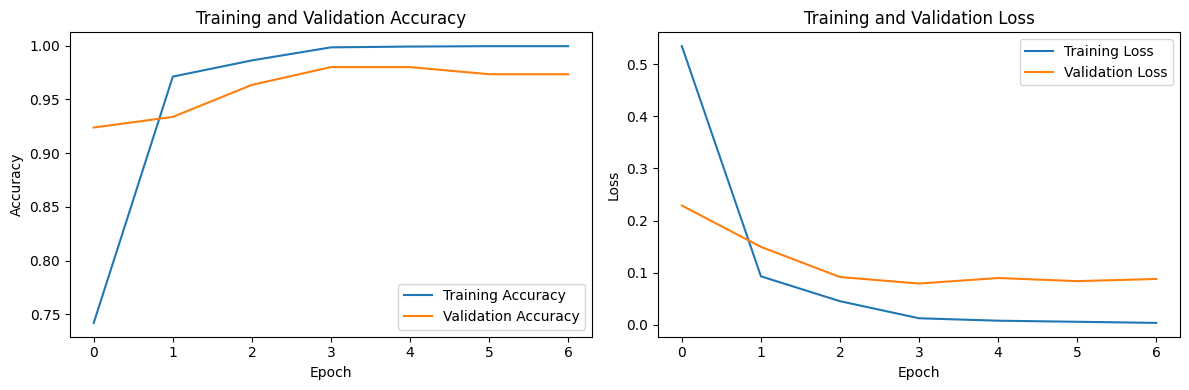

In [ ]:
# =======================
# 11. GRAFIK ACCURACY DAN LOSS
# =======================

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


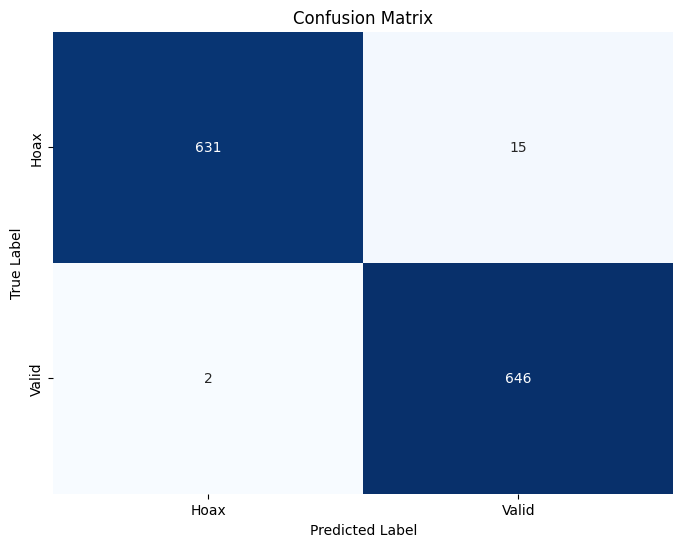

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np # Import numpy

# Assuming the model is already trained and X_test_pad and y_test_rnn are available

# Get predictions on the test data
y_pred_rnn = model.predict(X_test_pad)
y_pred_rnn = (y_pred_rnn > 0.5).astype(int) # Convert probabilities to binary predictions

# Calculate the confusion matrix
cm = confusion_matrix(y_test_rnn, y_pred_rnn)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Hoax', 'Valid'], yticklabels=['Hoax', 'Valid'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

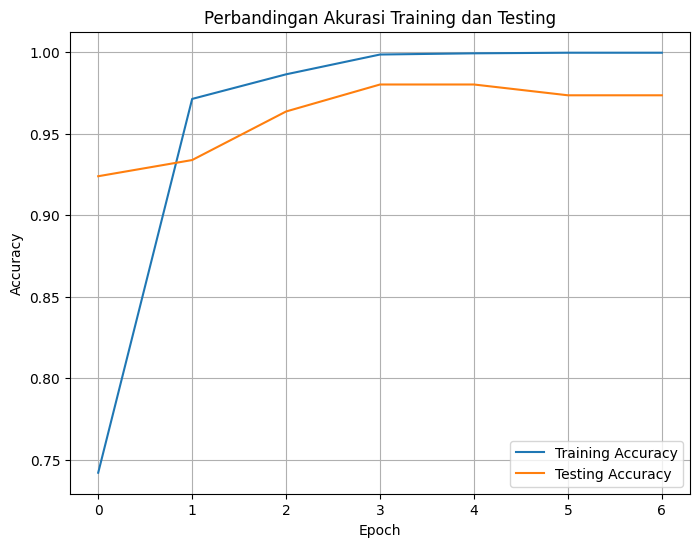

Final Training Accuracy: 0.9996
Final Testing Accuracy: 0.9735


In [ ]:
import matplotlib.pyplot as plt

# Assuming 'history' object is available from the model training
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Testing Accuracy') # 'val_accuracy' is the accuracy on the validation set, which is used as a proxy for testing accuracy here
plt.title('Perbandingan Akurasi Training dan Testing')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Display numerical accuracy values
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Testing Accuracy: {history.history['val_accuracy'][-1]:.4f}")

In [ ]:
import pandas as pd
import numpy as np

# Assume the model, tokenizer, max_len, and label_encoder are already defined and trained/fitted

# Create 5 example news texts for testing
example_news = [
    "Vaksin COVID-19 aman dan efektif melindungi dari penyakit.",
    "Teori konspirasi tentang virus corona menyebar luas di media sosial.",
    "Pemerintah mengumumkan paket bantuan ekonomi untuk masyarakat terdampak.",
    "Artikel ini mengklaim pengobatan alternatif bisa menyembuhkan kanker dalam semalam.",
    "Cuaca ekstrem diperkirakan terjadi di beberapa wilayah dalam minggu ini."
]

# Preprocess the example news texts
preprocessed_news = [preprocess_text(text) for text in example_news]

# Convert texts to sequences and pad
sequences = tokenizer.texts_to_sequences(preprocessed_news)
padded_sequences = pad_sequences(sequences, maxlen=max_len) # Use the same max_len used during training

# Make predictions
predictions = model.predict(padded_sequences)

# Convert predictions (probabilities) to binary labels (0 or 1)
predicted_labels_numeric = (predictions > 0.5).astype(int)

# Convert numerical labels back to original labels (hoax or real)
predicted_labels = le.inverse_transform(predicted_labels_numeric.flatten())

# Create a DataFrame to display the results
results_df = pd.DataFrame({
    'News Text': example_news,
    'Predicted Label': predicted_labels,
    'Score': predictions.flatten() # Display confidence score for the positive class (Valid)
})

print("Hasil Pengujian Model:")
display(results_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Hasil Pengujian Model:


,News Text,Predicted Label,Score
0,Vaksin COVID-19 aman dan efektif melindungi da...,hoax,0.126392
1,Teori konspirasi tentang virus corona menyebar...,valid,0.944938
2,Pemerintah mengumumkan paket bantuan ekonomi u...,valid,0.968788
3,Artikel ini mengklaim pengobatan alternatif bi...,valid,0.836327
4,Cuaca ekstrem diperkirakan terjadi di beberapa...,valid,0.986142


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Assuming y_test_rnn and y_pred_rnn are available from previous steps

# Calculate accuracy
accuracy = accuracy_score(y_test_rnn, y_pred_rnn)
print(f"Accuracy: {accuracy:.4f}\n")

# Generate classification report
print("Classification Report:")
print(classification_report(y_test_rnn, y_pred_rnn, target_names=['Hoax', 'Valid']))

Accuracy: 0.9869

Classification Report:
              precision    recall  f1-score   support

        Hoax       1.00      0.98      0.99       646
       Valid       0.98      1.00      0.99       648

    accuracy                           0.99      1294
   macro avg       0.99      0.99      0.99      1294
weighted avg       0.99      0.99      0.99      1294



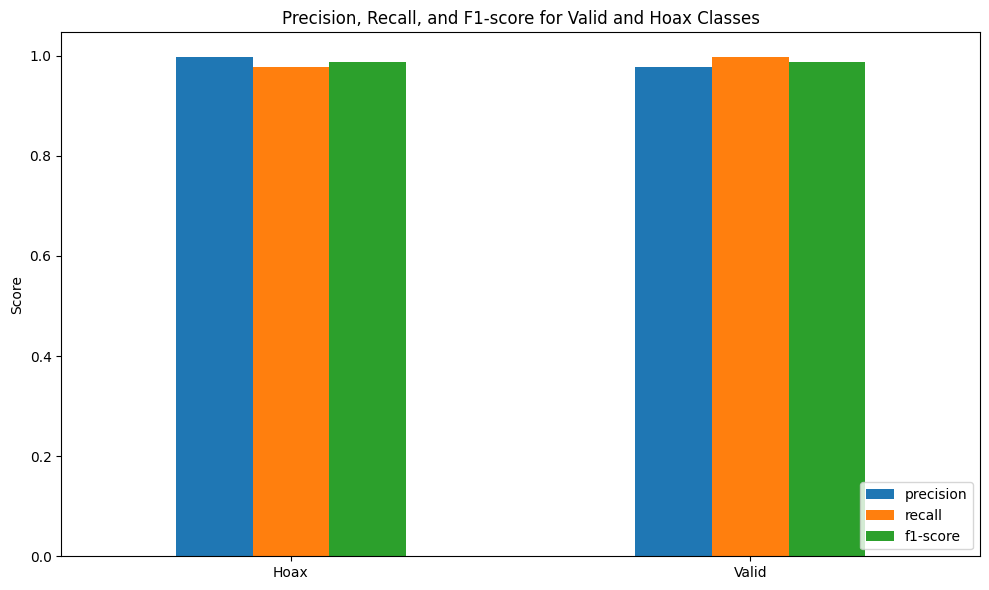

Overall Accuracy: 0.9869

Numerical Scores:
  Hoax:
    Precision: 0.9968
    Recall: 0.9768
    F1-score: 0.9867
  Valid:
    Precision: 0.9773
    Recall: 0.9969
    F1-score: 0.9870


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

# Assuming y_test_rnn and y_pred_rnn are available from previous steps

# Generate classification report as a dictionary
report = classification_report(y_test_rnn, y_pred_rnn, target_names=['Hoax', 'Valid'], output_dict=True)

# Convert the report to a pandas DataFrame for easier plotting
report_df = pd.DataFrame(report).transpose()

# Remove the 'accuracy', 'macro avg', and 'weighted avg' rows for the bar chart
report_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'])

# Plot precision, recall, and f1-score
report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(10, 6))
plt.title('Precision, Recall, and F1-score for Valid and Hoax Classes')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Display accuracy separately
accuracy = report['accuracy']
print(f"Overall Accuracy: {accuracy:.4f}")

# Display numerical precision, recall, and f1-score
print("\nNumerical Scores:")
for label in ['Hoax', 'Valid']:
    print(f"  {label}:")
    print(f"    Precision: {report[label]['precision']:.4f}")
    print(f"    Recall: {report[label]['recall']:.4f}")
    print(f"    F1-score: {report[label]['f1-score']:.4f}")